# Exploratory Data Analysis – Travel Data

Dieses Notebook führt eine explorative Datenanalyse (EDA) auf dem bereinigten Reisedaten-Datensatz `traveldataexport_clean.xlsx` durch. Ziel ist es, die Struktur, Verteilungen und potenziellen Muster (insbesondere im Hinblick auf CO₂-Emissionen, Kosten und Verkehrsmittel) zu verstehen, um darauf aufbauend Visualisierungen zu konzipieren.

**Inhalt:**
1. Setup & Datenimport
2. Datenstruktur & Data Dictionary
3. Datenqualität (Missing Values, Duplikate, Wertebereiche)
4. Univariate Analyse (kategorial & numerisch)
5. Zeitliche Entwicklung
6. Bivariate / multivariate Zusammenhänge
7. Geografische Analyse
8. CO₂-Budget-Vergleich
9. Erste Erkenntnisse & nächste Schritte

## 1. Setup & Datenimport

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 200)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

In [26]:
# Pfad zur Excel-Datei – ggf. anpassen
DATA_PATH = Path('../data_acquisition/data_clean/traveldata-export_clean.xlsx')


df = pd.read_excel(DATA_PATH, sheet_name='travel_data')
data_dict = pd.read_excel(DATA_PATH, sheet_name='data_dictionary')
budget_2026 = pd.read_excel(DATA_PATH, sheet_name='budget_2026')
co2_budgets = pd.read_excel(DATA_PATH, sheet_name='co2_budgets')

print(f'travel_data:    {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten')
print(f'data_dictionary: {data_dict.shape}')
print(f'budget_2026:     {budget_2026.shape}')
print(f'co2_budgets:     {co2_budgets.shape}')

travel_data:    25,527 Zeilen × 20 Spalten
data_dictionary: (19, 3)
budget_2026:     (5, 4)
co2_budgets:     (100, 3)


## 2. Datenstruktur & Data Dictionary

In [27]:
data_dict

,Column,Type,Description
0,person_type,text,Employee or external guest travelling on behalf of the company.
1,date,date,Date of the trip segment.
2,transport_mode,text,"Mode of transport: flight, train, bus, or rental_car."
3,departure_iata,text,IATA code of the departure airport / city (e.g. ZRH = Zurich).
4,arrival_iata,text,IATA code of the arrival airport / city.
5,CO2e RFI2 (t),number,CO2-equivalent emissions in tonnes using a Radiative Forcing Index of 2.
6,CO2e RFI2.7 (t),number,CO2-equivalent emissions in tonnes using a Radiative Forcing Index of 2.7 (accounts for non-CO2 effects at altitude). Equal to RFI2 value for ground transport.
7,km,number,Great-circle distance in kilometres.
8,haul,text,"Distance category: short haul (< ~1500 km), mid haul, long haul, or ground (train/bus/car)."
9,departure_lat,number,Departure latitude (WGS 84).


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25527 entries, 0 to 25526
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   person_type                  25527 non-null  object        
 1   date                         25527 non-null  datetime64[ns]
 2   transport_mode               25527 non-null  object        
 3   departure_iata               25527 non-null  object        
 4   arrival_iata                 25527 non-null  object        
 5   CO2e RFI2 (t)                25527 non-null  float64       
 6   CO2e RFI2.7 (t)              25527 non-null  float64       
 7   km                           25527 non-null  int64         
 8   haul                         25527 non-null  object        
 9   departure_country            25527 non-null  object        
 10  departure_lat                25527 non-null  float64       
 11  departure_lon                25527 non-nu

In [29]:
df.head()

,person_type,date,transport_mode,departure_iata,arrival_iata,CO2e RFI2 (t),CO2e RFI2.7 (t),km,haul,departure_country,departure_lat,departure_lon,arrival_country,arrival_lat,arrival_lon,business_unit,budget_2026,travel_purpose,cost_CHF,train_alternative_available
0,employee,2017-01-01,flight,ZRH,DUS,0.0702,0.0921,494,short haul,CH,47.458056,8.548056,DE,51.289501,6.766780,BU3,240.9,workshop,233.59,True
1,employee,2017-01-01,flight,ZRH,VIE,0.0982,0.1356,704,short haul,CH,47.458056,8.548056,AT,48.110298,16.569700,BU2,211.5,client_meeting,338.01,True
2,employee,2017-01-01,flight,AMS,TSE,0.7264,1.0784,4534,long haul,NL,52.308601,4.763890,KZ,71.466904,51.022202,BU2,211.5,trade_fair,5826.85,False
3,employee,2017-01-01,flight,ZRH,AMS,0.1269,0.1752,702,short haul,CH,47.458056,8.548056,NL,52.308601,4.763890,BU3,240.9,trade_fair,871.96,True
4,employee,2017-01-01,flight,AMS,ZRH,0.1269,0.1752,702,short haul,NL,52.308601,4.763890,CH,47.458056,8.548056,BU4,181.2,client_meeting,1043.21,True


## 3. Datenqualität

Wir prüfen Missing Values, Duplikate, Wertebereiche und einfache Plausibilitätschecks.

In [30]:
# Missing Values
missing = df.isna().sum()
missing

person_type                    0
date                           0
transport_mode                 0
departure_iata                 0
arrival_iata                   0
CO2e RFI2 (t)                  0
CO2e RFI2.7 (t)                0
km                             0
haul                           0
departure_country              0
departure_lat                  0
departure_lon                  0
arrival_country                0
arrival_lat                    0
arrival_lon                    0
business_unit                  0
budget_2026                    0
travel_purpose                 0
cost_CHF                       0
train_alternative_available    0
dtype: int64

In [31]:
# Duplikate
dupes = df.duplicated().sum()
print(f'Vollständig identische Zeilen: {dupes:,}')

# Plausibilität
print(f"\nNegative km:        {(df['km'] < 0).sum()}")
print(f"Negative CO2 RFI2:  {(df['CO2e RFI2 (t)'] < 0).sum()}")
print(f"Negative Kosten:    {(df['cost_CHF'] < 0).sum()}")
print(f"\nDatumsbereich: {df['date'].min().date()} – {df['date'].max().date()}")

Vollständig identische Zeilen: 0

Negative km:        0
Negative CO2 RFI2:  0
Negative Kosten:    0

Datumsbereich: 2017-01-01 – 2026-01-05


In [32]:
# Statistische Zusammenfassung der numerischen Spalten
df.describe()

,date,CO2e RFI2 (t),CO2e RFI2.7 (t),km,departure_lat,departure_lon,arrival_lat,arrival_lon,budget_2026,cost_CHF
count,25527,25527.000000,25527.000000,25527.000000,25527.000000,25527.000000,25527.000000,25527.000000,25527.000000,25527.000000
mean,2021-09-10 21:51:16.225173248,0.295678,0.424176,1904.757120,43.813190,6.389089,43.923560,6.167717,211.257813,740.074456
min,2017-01-01 00:00:00,0.001100,0.001100,125.000000,-41.327202,-157.924228,-41.327202,-157.924228,181.200000,17.460000
25%,2018-11-01 00:00:00,0.022400,0.022400,494.000000,45.764000,6.766780,45.764000,6.108950,207.500000,214.980000
50%,2022-06-27 00:00:00,0.101400,0.140900,750.000000,47.458056,8.548056,47.458056,8.548056,211.500000,434.050000
75%,2024-05-15 00:00:00,0.209450,0.304300,1587.000000,48.856600,11.100400,49.012798,11.404100,240.900000,659.125000
max,2026-01-05 00:00:00,11.070100,16.521800,18803.000000,71.466904,174.804993,71.466904,174.804993,240.900000,17273.180000
std,NaN,0.519022,0.760527,2689.872366,14.527143,36.364472,14.393751,36.433508,21.004053,1233.260552


## 4. Univariate Analyse

### 4.1 Kategoriale Variablen

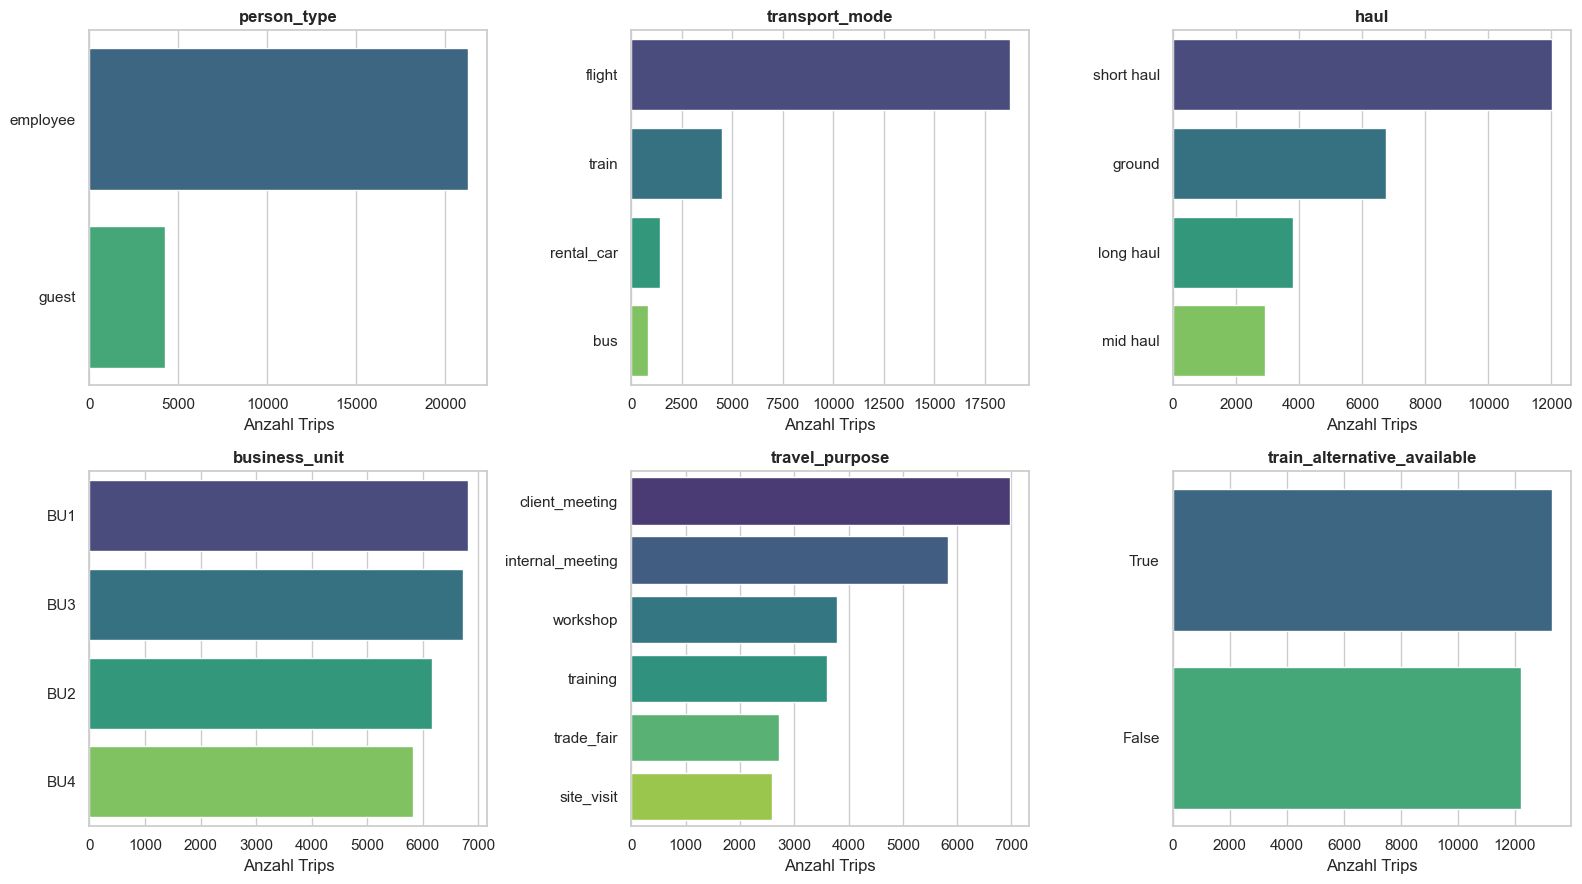

In [33]:
cat_cols = ['person_type', 'transport_mode', 'haul', 'business_unit',
            'travel_purpose', 'train_alternative_available']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax,
                hue=counts.index.astype(str), legend=False, palette='viridis')
    ax.set_title(col)
    ax.set_xlabel('Anzahl Trips')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 4.2 Numerische Variablen

Aufgrund stark schiefer Verteilungen (Long-Tail bei Distanz/CO₂/Kosten) zeigen wir die Rohverteilung und eine log-skalierte Variante.

In [34]:
num_cols = ['km', 'CO2e RFI2 (t)']

# fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 3 * len(num_cols)))
# for i, col in enumerate(num_cols):
#     sns.histplot(df[col], bins=50, ax=axes[i, 0], color='steelblue')
#     axes[i, 0].set_title(f'{col} – linear')
#     sns.histplot(df[col], bins=50, ax=axes[i, 1], color='steelblue', log_scale=True)
#     axes[i, 1].set_title(f'{col} – log-skala')
# plt.tight_layout()
# plt.show()

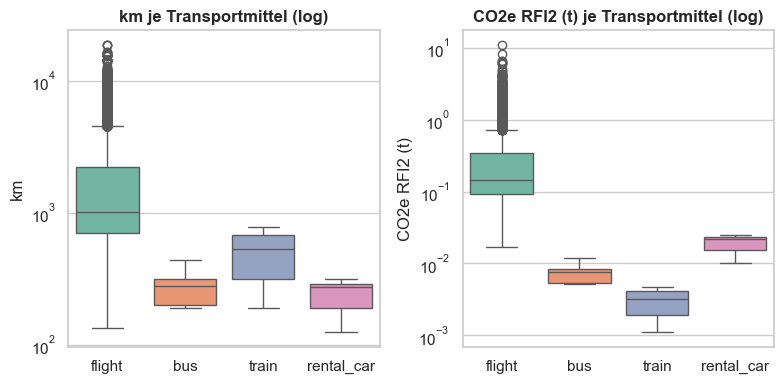

In [35]:
# Boxplots der numerischen Variablen je Verkehrsmittel
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x='transport_mode', y=col, ax=ax,
                hue='transport_mode', legend=False, palette='Set2')
    ax.set_yscale('log')
    ax.set_title(f'{col} je Transportmittel (log)')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 5. Zeitliche Entwicklung

Wir aggregieren auf Jahres- und Monatsebene, um Trends und saisonale Muster zu erkennen (insb. COVID-Effekt 2020/21).

In [36]:
df['year'] = df['date'].dt.year
df['year_month'] = df['date'].dt.to_period('M').dt.to_timestamp()

# # Anzahl Trips, CO2 und Kosten pro Jahr
# yearly = df.groupby('year').agg(
#     trips=('date', 'count'),
#     km=('km', 'sum'),
#     co2_t=('CO2e RFI2.7 (t)', 'sum'),
#     cost_CHF=('cost_CHF', 'sum'),
# ).round(1)
# yearly

In [37]:
# fig, axes = plt.subplots(2, 2, figsize=(14, 8))
# yearly['trips'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
# axes[0, 0].set_title('Anzahl Trips pro Jahr')
# yearly['km'].plot(kind='bar', ax=axes[0, 1], color='darkorange') 
# axes[0, 1].set_title('Gesamtdistanz (km) pro Jahr')
# yearly['co2_t'].plot(kind='bar', ax=axes[1, 0], color='seagreen')
# axes[1, 0].set_title('CO₂e RFI2.7 (t) pro Jahr')
# yearly['cost_CHF'].plot(kind='bar', ax=axes[1, 1], color='firebrick')
# axes[1, 1].set_title('Kosten (CHF) pro Jahr')
# for ax in axes.flat:
#     ax.set_xlabel('')
# plt.tight_layout()
# plt.show()

In [38]:
# # Monatlicher CO2-Verlauf nach Transportmittel
# monthly_mode = (df.groupby(['year_month', 'transport_mode'])['CO2e RFI2.7 (t)']
#                   .sum().reset_index())

# plt.figure(figsize=(14, 5))
# sns.lineplot(data=monthly_mode, x='year_month', y='CO2e RFI2.7 (t)',
#              hue='transport_mode', palette='Set2')
# plt.title('Monatliche CO₂-Emissionen nach Transportmittel')
# plt.xlabel('')
# plt.ylabel('CO₂e RFI2.7 (t)')
# plt.legend(title='Transportmittel')
# plt.tight_layout()
# plt.show()

## 6. Bivariate / multivariate Zusammenhänge

### 6.1 Korrelationen numerischer Variablen

In [39]:
# # km vs. CO2 nach Transportmittel
# sample = df.sample(min(5000, len(df)), random_state=42)
# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=sample, x='km', y='CO2e RFI2.7 (t)',
#                 hue='transport_mode', alpha=0.5, palette='Set2', s=15)
# plt.xscale('log')
# plt.yscale('log')
# plt.title('Distanz vs. CO₂-Emissionen (log-log, Stichprobe)')
# plt.tight_layout()
# plt.show()

### 6.2 CO₂ und Kosten je Business Unit

In [40]:
by_bu = df.groupby('business_unit').agg(
    trips=('date', 'count'),
    co2_t=('CO2e RFI2.7 (t)', 'sum'),
    cost_CHF=('cost_CHF', 'sum'),
    km=('km', 'sum'),
).round(1).sort_index()
by_bu

,trips,co2_t,cost_CHF,km
business_unit,,,,
BU1,6821,2594.8,4662994.7,11918684
BU2,6164,2640.4,4619300.6,11877447
BU3,6719,3232.0,5438013.5,14137101
BU4,5823,2360.7,4171571.8,10689503


### 6.3 Reisezweck und Verkehrsmittel

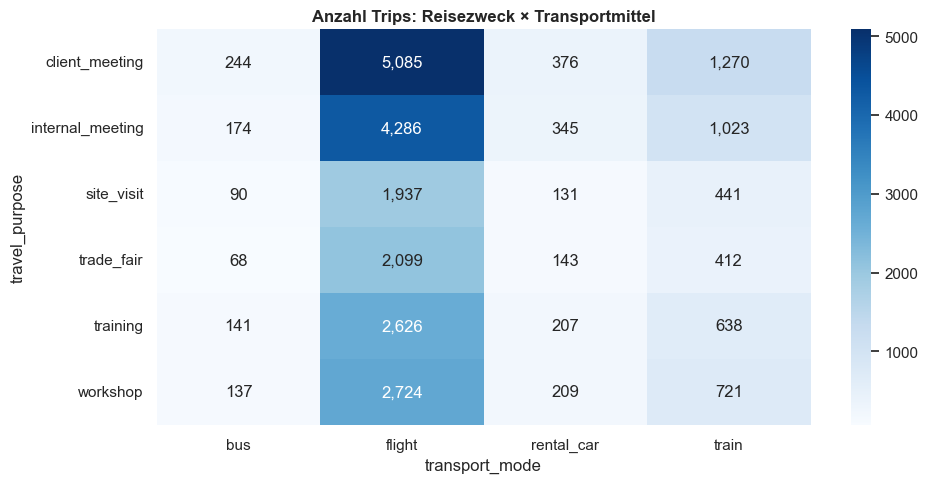

In [41]:
purpose_mode = pd.crosstab(df['travel_purpose'], df['transport_mode'])
plt.figure(figsize=(10, 5))
sns.heatmap(purpose_mode, annot=True, fmt=',d', cmap='Blues')
plt.title('Anzahl Trips: Reisezweck × Transportmittel')
plt.tight_layout()
plt.show()

### 6.4 Bahn-Alternative verfügbar – aber Flug genommen?

Eine besonders interessante Frage: Wie viele Flüge wurden trotz verfügbarer Bahnverbindung gebucht? (`train_alternative_available == True` & `transport_mode == 'flight'`)

In [42]:
flights_with_train = df[(df['transport_mode'] == 'flight') &
                        (df['train_alternative_available'] == True)]
all_flights = df[df['transport_mode'] == 'flight']

share = len(flights_with_train) / len(all_flights) * 100
print(f'Flüge mit verfügbarer Bahn-Alternative: {len(flights_with_train):,} '
      f'von {len(all_flights):,} ({share:.1f} %)')
print(f"Vermeidbare CO₂-Emissionen (RFI2.7): {flights_with_train['CO2e RFI2.7 (t)'].sum():.1f} t")
print(f"Vermeidbare Kosten:                  {flights_with_train['cost_CHF'].sum():,.0f} CHF")

Flüge mit verfügbarer Bahn-Alternative: 6,530 von 18,757 (34.8 %)
Vermeidbare CO₂-Emissionen (RFI2.7): 753.5 t
Vermeidbare Kosten:                  2,880,568 CHF


/var/folders/d3/491fzvvs5lg2864030mq9_lw0000gn/T/ipykernel_46196/2074759783.py:12: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


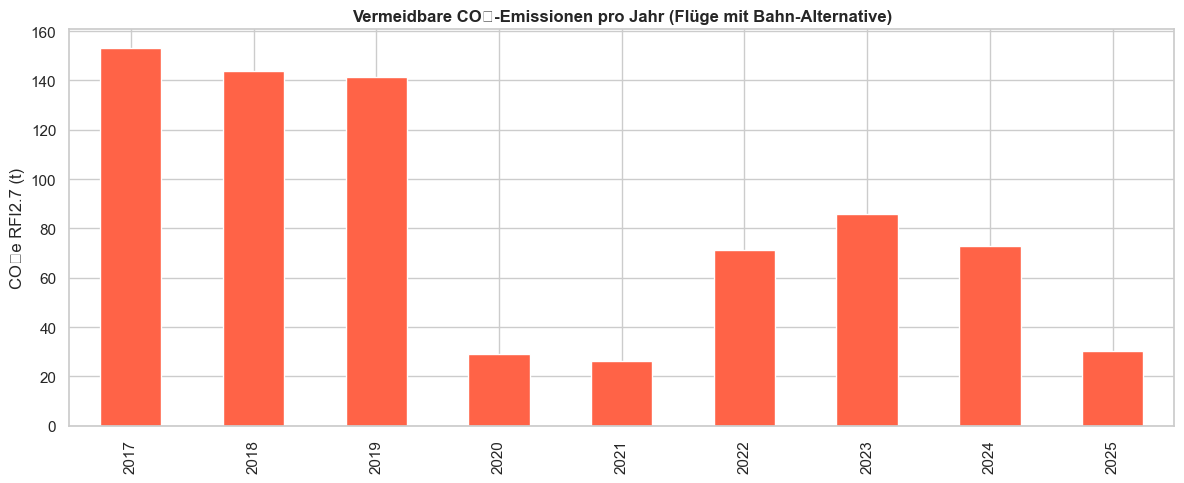

In [43]:
# Über die Jahre
avoidable = (flights_with_train.groupby('year')
             .agg(trips=('date', 'count'),
                  co2_t=('CO2e RFI2.7 (t)', 'sum'),
                  cost_CHF=('cost_CHF', 'sum')))

fig, ax = plt.subplots(figsize=(12, 5))
avoidable['co2_t'].plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Vermeidbare CO₂-Emissionen pro Jahr (Flüge mit Bahn-Alternative)')
ax.set_ylabel('CO₂e RFI2.7 (t)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 7. Geografische Analyse

In [44]:
# # Top Zielländer nach Anzahl & nach CO2
# top_count = (df['arrival_country'].value_counts().head(15))
# top_co2 = (df.groupby('arrival_country')['CO2e RFI2.7 (t)']
#              .sum().sort_values(ascending=False).head(15))

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# sns.barplot(x=top_count.values, y=top_count.index, ax=axes[0],
#             hue=top_count.index, legend=False, palette='Blues_r')
# axes[0].set_title('Top 15 Zielländer nach Anzahl Trips')
# sns.barplot(x=top_co2.values, y=top_co2.index, ax=axes[1],
#             hue=top_co2.index, legend=False, palette='Greens_r')
# axes[1].set_title('Top 15 Zielländer nach CO₂ (t)')
# plt.tight_layout()
# plt.show()

In [45]:
# # Top-Strecken (von – nach) nach Anzahl
# df['route'] = df['departure_iata'] + ' → ' + df['arrival_iata']
# top_routes = df['route'].value_counts().head(20)

# plt.figure(figsize=(10, 7))
# sns.barplot(x=top_routes.values, y=top_routes.index,
#             hue=top_routes.index, legend=False, palette='mako')
# plt.title('Top 20 Strecken (Departure → Arrival)')
# plt.xlabel('Anzahl Trips')
# plt.tight_layout()
# plt.show()

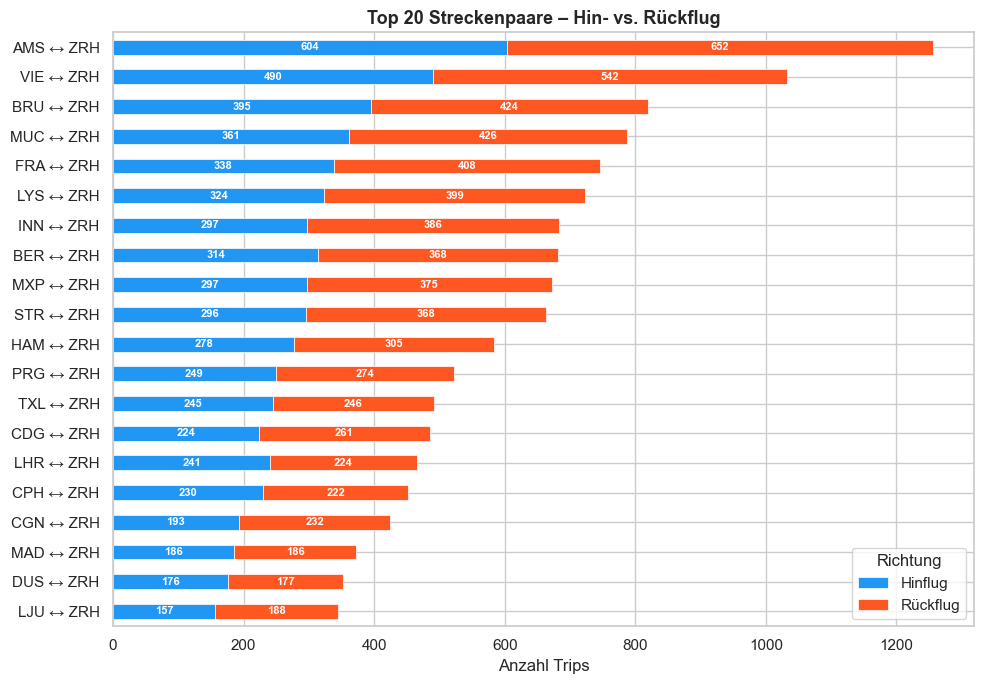

In [46]:
# Kanonische Route (alphabetisch sortiert) und Richtung bestimmen
df['route'] = df['departure_iata'] + ' → ' + df['arrival_iata']
df['route_pair'] = df.apply(
    lambda r: ' ↔ '.join(sorted([r['departure_iata'], r['arrival_iata']])), axis=1
)
df['direction'] = df.apply(
    lambda r: 'Hinflug' if r['departure_iata'] <= r['arrival_iata'] else 'Rückflug', axis=1
)

# Top 20 Streckenpaare nach Gesamtanzahl
top_pairs = df['route_pair'].value_counts().head(20).index
df_top = df[df['route_pair'].isin(top_pairs)]

# Pivot: Streckenpaare × Richtung
pivot = (
    df_top.groupby(['route_pair', 'direction'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Hinflug', 'Rückflug'], fill_value=0)
)

# Sortieren nach Gesamtanzahl
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=True).index]

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

pivot.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#2196F3', '#FF5722'],
    edgecolor='white',
    linewidth=0.5
)

# Beschriftungen in die Balken
for i, (idx, row) in enumerate(pivot.iterrows()):
    x_offset = 0
    for val, color in zip(row, ['white', 'white']):
        if val > 0:
            ax.text(
                x_offset + val / 2, i, str(val),
                va='center', ha='center', fontsize=8, color=color, fontweight='bold'
            )
        x_offset += val

ax.set_title('Top 20 Streckenpaare – Hin- vs. Rückflug', fontsize=13, fontweight='bold')
ax.set_xlabel('Anzahl Trips')
ax.set_ylabel('')
ax.legend(title='Richtung', loc='lower right')
plt.tight_layout()
plt.show()

## 8. CO₂-Budget-Vergleich

Wir vergleichen die tatsächlichen CO₂-Emissionen mit den hinterlegten CO₂-Budgets pro Subunit (Sheet `co2_budgets`) sowie die Budget-Übersicht 2026.

In [47]:
print('budget_2026 (Übersicht):')
display(budget_2026)


budget_2026 (Übersicht):


,Business Unit,2024,2025,2026 (Prognose)
0,BU1,"253,7","230,6","207,5"
1,BU2,"258,5",235,"211,5"
2,BU3,"294,5","267,7","240,9"
3,BU4,"220,8","200,6","181,2"
4,Total,"1.027,50","933,9","841,1"


In [52]:
# CO2 pro Business Unit & Jahr vs. Budget (auf BU-Ebene aggregieren)
actual_bu_year = (df.groupby(['business_unit', 'year'])['CO2e RFI2.7 (t)']
                    .sum().reset_index(name='actual_co2_t'))

# Subunit X.Y -> BU X (annahme)
co2_budgets_bu = co2_budgets.copy()
co2_budgets_bu['business_unit'] = ('BU' + co2_budgets_bu['subunit']
                                   .str.extract(r'Subunit (\d)')[0])
budget_bu_year = (co2_budgets_bu.groupby(['business_unit', 'year'])['co2_budget_t']
                                 .sum(min_count=1).reset_index())

comparison = actual_bu_year.merge(budget_bu_year, on=['business_unit', 'year'], how='left')
comparison.head(12)

,business_unit,year,actual_co2_t,co2_budget_t
0,BU1,2017,341.5022,NaN
1,BU1,2018,344.8364,NaN
2,BU1,2019,483.1885,NaN
3,BU1,2020,115.8244,329.4
4,BU1,2021,35.5168,329.4
5,BU1,2022,267.0929,303.1
6,BU1,2023,364.4240,276.8
7,BU1,2024,363.0510,253.7
8,BU1,2025,279.3387,230.6
9,BU2,2017,353.6618,NaN


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


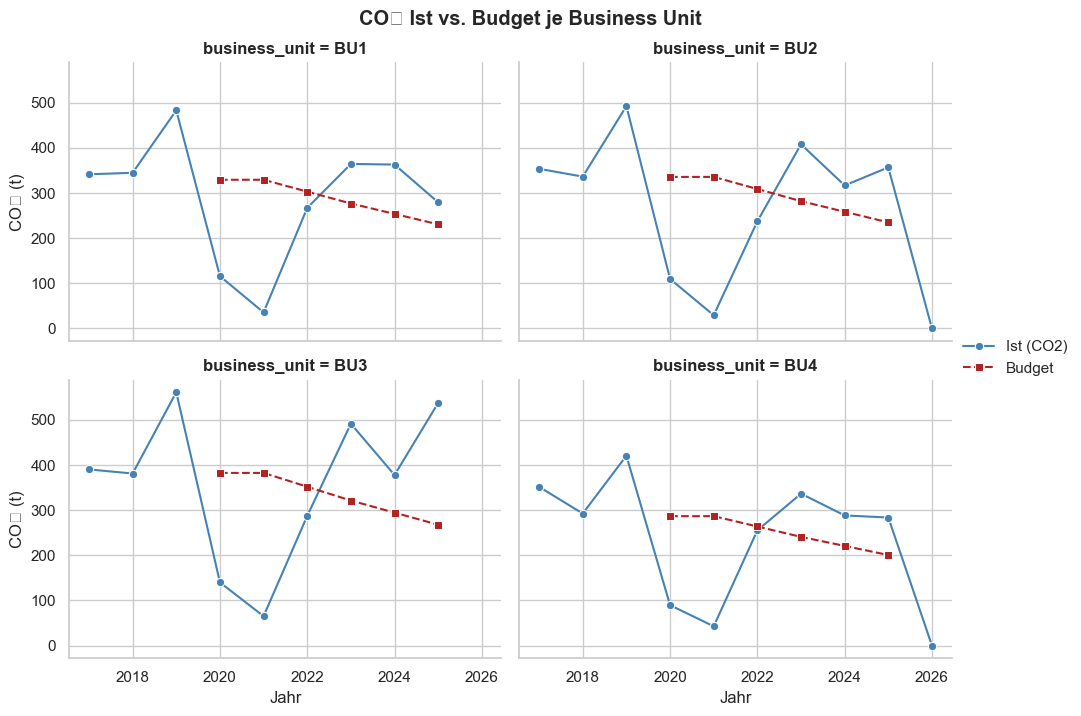

In [ ]:
g = sns.FacetGrid(comparison, col='business_unit', col_wrap=2, height=3.5, aspect=1.4)
g.map_dataframe(sns.lineplot, x='year', y='actual_co2_t',
                marker='o', label='Ist (CO2)', color='steelblue')
g.map_dataframe(sns.lineplot, x='year', y='co2_budget_t',
                marker='s', label='Budget', color='firebrick', linestyle='--')
g.set_axis_labels('Jahr', 'CO₂ (t)')
g.add_legend()
g.fig.suptitle('CO₂ Ist vs. Budget je Business Unit', y=1.02, fontweight='bold')
plt.show()

## 9. Erste Erkenntnisse & nächste Schritte

**Erste Beobachtungen** (vorläufig, basierend auf den oben gezeigten Verteilungen):

- Der Datensatz umfasst rund **25 500 Trips** über den Zeitraum 2017–2026 mit vier Transportmitteln (Flug, Zug, Bus, Mietwagen).
- **Flüge** dominieren sowohl die Anzahl der Trips als auch die CO₂-Emissionen, obwohl ein bedeutender Anteil von Flügen eine **verfügbare Bahnalternative** hat – dies ist ein wichtiger Hebel.
- Die **CO₂-Verteilung ist stark rechtsschief**: wenige Langstreckenflüge verursachen einen großen Teil der Emissionen.
- Es zeigt sich ein klarer **COVID-Einbruch 2020/21** und eine darauffolgende Erholung.
- Die Business Units unterscheiden sich in Reisevolumen und CO₂-Anteil; ein **Soll-/Ist-Vergleich** mit den hinterlegten Budgets liefert weitere Story-Potenziale.

**Mögliche nächste Schritte für die Visualisierung / Modellierung:**

- Detaillierte Analyse vermeidbarer Flüge (Bahnalternative) als Kern-Story.
- Geografische Karte der Top-Strecken mit CO₂ als Linienstärke.
- Forecast/Trend für 2026 vs. Budget-Werte aus `budget_2026`.
- Drill-down: Reisezweck → Transportmittel → CO₂ pro BU.